In [5]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Import Database
conn = sqlite3.connect('customer_churn_db.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

# Create Database to store table names
for table_name in tables['name']:
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
  globals()[f"df_{table_name}"] = df
  print(f"Created DataFrame : df{table_name}")

conn.close()

Created DataFrame : dfdb_customer
Created DataFrame : dfdb_subscription
Created DataFrame : dfdb_support


In [7]:
# Print table names and column names
conn = sqlite3.connect('customer_churn_db.db')

for table_name in tables['name']:
  print(f"\nTable Name: {table_name}")
  # Fetch Column Information
  column_query = f"PRAGMA table_info({table_name})" # PRAGMA used to get info from database
  columns = pd.read_sql(column_query, conn)
  print("Columns:")
  print(columns['name'].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


---

# Data Cleaning

In [8]:
df_db_customer.head()
# df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN


In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  500 non-null    object 
 1   name        500 non-null    object 
 2   country     497 non-null    object 
 3   state       500 non-null    object 
 4   gender      500 non-null    object 
 5   dob         500 non-null    object 
 6   interests   483 non-null    object 
 7   pincode     479 non-null    float64
dtypes: float64(1), object(7)
memory usage: 31.4+ KB


In [10]:
df_db_customer.isnull().sum()

customerid     0
name           0
country        3
state          0
gender         0
dob            0
interests     17
pincode       21
dtype: int64

In [11]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [12]:
# 1. rename name - customer_name
# 2. drop column - interest and pincode
# 3. convert data type of col - dob to datetime
# 4. data standarization - gender
# 5. fix missing values - country

In [13]:
# 1. rename name - customer_name
df_db_customer.rename(columns={'name':'customer_name'}, inplace=True)

In [14]:
# 2. drop column - interest and pincode
df_db_customer.drop(columns=['interests','pincode'], axis=1, inplace=True)

In [15]:
# 3. convert data type of col - dob to datetime
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [16]:
# 4. data standarization - gender
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male', 'Women':'Female'})

In [17]:
# 5. fix missing values - country
df_db_customer['country'].unique()

array(['India', None, 'Nepal'], dtype=object)

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [19]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [20]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer.isnull().sum()

customerid       0
customer_name    0
country          0
state            0
gender           0
dob              0
dtype: int64

---

In [22]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [23]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               500 non-null    object 
 1   subscription_start_date  500 non-null    object 
 2   subscription_type        500 non-null    object 
 3   renewal_date             500 non-null    object 
 4   plan_type                500 non-null    object 
 5   contract_type            500 non-null    object 
 6   cancellation_date        137 non-null    object 
 7   cancellation_reason      137 non-null    object 
 8   monthly_charges          500 non-null    float64
 9   cltv                     500 non-null    int64  
 10  churn_score              500 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 43.1+ KB


In [24]:
df_db_subscription.isnull().sum()

customerid                   0
subscription_start_date      0
subscription_type            0
renewal_date                 0
plan_type                    0
contract_type                0
cancellation_date          363
cancellation_reason        363
monthly_charges              0
cltv                         0
churn_score                  0
dtype: int64

In [25]:
date_col = ['subscription_start_date', 'renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

---

In [26]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,NaN,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,NaN,None


In [27]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      144 non-null    object 
 1   complaint_date  144 non-null    object 
 2   escalations     144 non-null    object 
 3   csat_score      144 non-null    int64  
 4   col_1           135 non-null    float64
 5   comment         139 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.9+ KB


In [28]:
df_db_support.drop(columns = ['col_1', 'comment'], inplace=True)

In [29]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

---

# Feature Engineering

In [30]:
# Created a new column 'churned' in df_db_subscription to indicate whether a customer has churned or not
df_db_subscription['churned'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [31]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churned
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [32]:
df_db_subscription.shape

(500, 12)

In [33]:
df_db_subscription['customerid'].nunique()

500

In [34]:
df_db_customer['customerid'].nunique()

500

In [35]:
df_db_support['customerid'].nunique()

103

In [36]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
139,NEW-0469,2024-12-19,Y,40
140,NEW-0472,2024-04-07,N,60
141,NEW-0477,2023-04-17,N,80
142,NEW-0478,2024-09-03,Y,50


In [37]:
df_db_support['customerid'].shape

(144,)

In [38]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [39]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [40]:
# merge df
df = (df_db_subscription
                .merge(df_db_customer, on='customerid', how='left')
                .merge(df_db_support, on='customerid', how='left')
)

In [41]:
df.shape

(500, 21)

In [42]:
df.to_csv('churn_data.csv', index=False)

---

# Data Analysis

In [43]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churned', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [44]:
# 1. Churn Rate
churn_rate = df['churned'].mean()*100
print("Churn Rate : ", round(churn_rate, 2), "%")

Churn Rate :  27.4 %


In [45]:
# 2. Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate : ", round(retention_rate, 2), "%")

Retention Rate :  72.6 %


In [46]:
# 3. Churn by plan type
churn_by_plan = (df.groupby('plan_type')['churned'].mean().mul(100).round(2).reset_index(name='churn_by_plan'))
print(churn_by_plan)

  plan_type  churn_by_plan
0     Basic          31.42
1   Premium          20.51
2  Standard          25.51


In [47]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churned,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [48]:
# 4. Churn by state
churn_by_state = (df.groupby('state')['churned'].mean().mul(100).round(2).reset_index(name='churn_by_state'))
print(churn_by_state)

            state  churn_by_state
0           Delhi           28.57
1         Gujarat           27.66
2         Haryana           17.95
3       Karnataka           36.73
4       Kathmandu            0.00
5     Maharashtra           30.00
6       Meghalaya           66.67
7        Nagaland            0.00
8          Punjab           27.91
9       Rajasthan           21.21
10     Tamil Nadu           28.57
11      Telangana           50.00
12  Uttar Pradesh           23.21
13    West Bengal           31.25


In [49]:
# 5. churn by subscription type
churn_by_subscription = (df.groupby('subscription_type')['churned'].mean().mul(100).round(2).reset_index(name='churn_by_subscription'))
print(churn_by_subscription)

  subscription_type  churn_by_subscription
0           Organic                  26.21
1              Paid                  33.10
2          Refferal                  22.73


In [50]:
# 6. ARPU = average revenue per user
arpu = df['monthly_charges'].mean()
print("ARPU : ",round(arpu, 2))

ARPU :  13.74


In [51]:
# 7. Avg Customer Tenure
# count of days between subscription start date and cancellation date

today = pd.Timestamp.today()
df['Tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

In [52]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,Tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1972.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1357.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2647.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [53]:
avg_tenure = df['Tenure_days'].mean()
print("Average Customer Tenure : ", round(avg_tenure, 0), "days")

Average Customer Tenure :  1105.0 days


In [54]:
# 8. Revenue at risk - revenue lost from churned customers
revenue_at_risk = df.loc[df['churned'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs) = ", revenue_at_risk)

Revenue at Risk (Rs) =  1740.6299999999999


In [55]:
# 9. Escalation Rate
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Escalation Rate : ", round(escalation_rate, 2), "%")

Escalation Rate :  11.4 %


In [56]:
# 10. Average Complaint Per User
avg_complaint_per_user = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Complaint Per User : ", round(avg_complaint_per_user, 2))

Average Complaint Per User :  0.29


In [57]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # Encoding

In [58]:
# 11. Correlation Between escaltions and churned
corr_df = df[['escalations', 'churned']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churned'])
print("Correlation Between Escalations and Churned : ", round(correlation, 2))

Correlation Between Escalations and Churned :  0.25


In [59]:
# 12. Churn risk = create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['Low', 'Medium', 'High']
df['churn_risk'] = np.select(conditions, choices, default='Unknown')

In [60]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,Tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1972.0,Low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,High
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1357.0,Low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2647.0,Low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,High


---

# Data Visualization

In [61]:
df_visual = df.copy()

In [62]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,Tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1972.0,Low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,High
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1357.0,Low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2647.0,Low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,High


In [63]:
# Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_date'] = df_visual['cancellation_date'].dt.to_period('M')

In [64]:
churn_trend = df_visual[df_visual['churned'] == 1].groupby('cancellation_date').size()

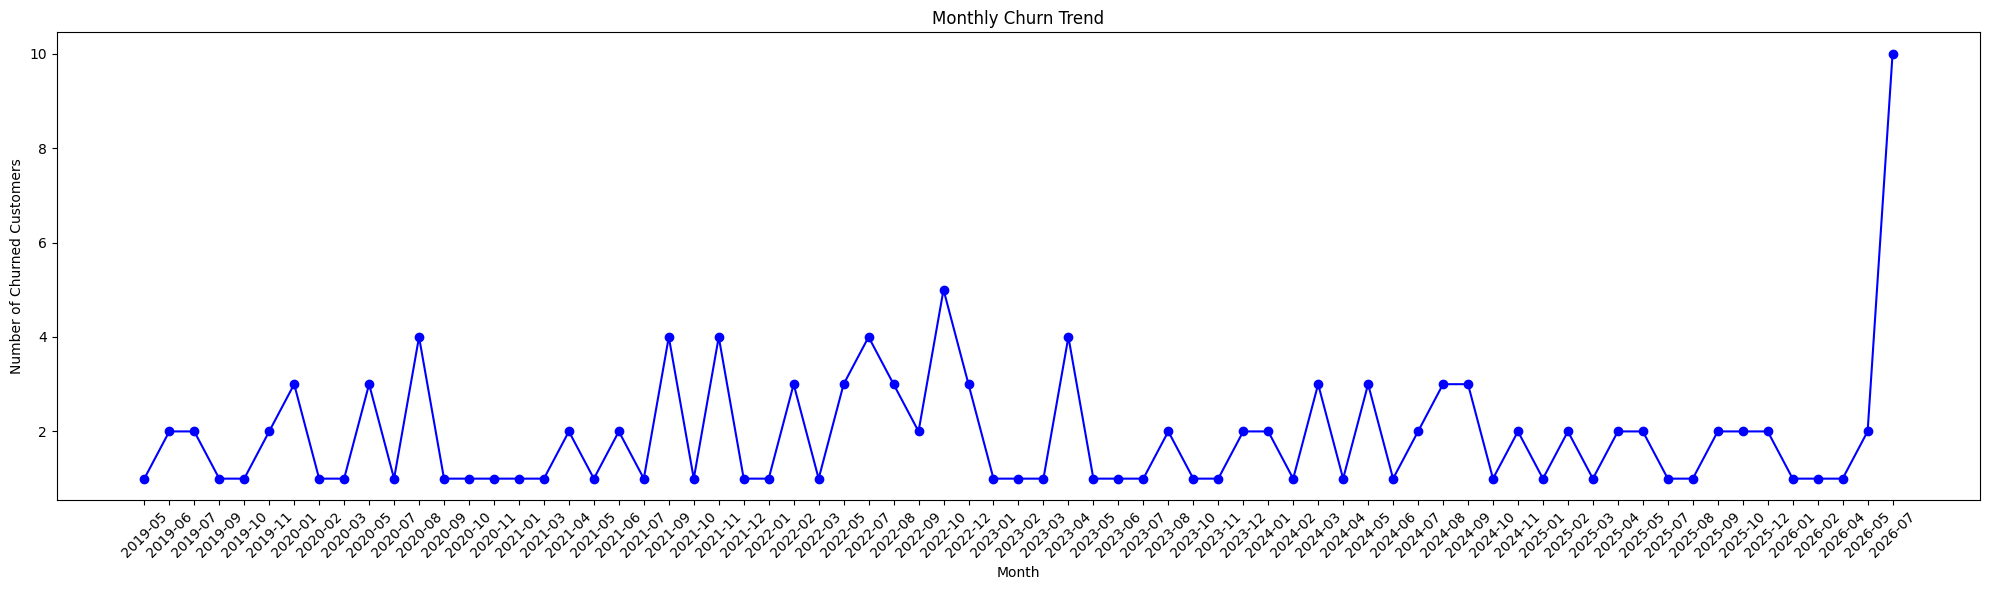

In [65]:
plt.figure(figsize=(20, 6))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, marker='o', linestyle='-', color='b')
plt.xlabel('Month')
plt.ylabel('Number of Churned Customers')
plt.title('Monthly Churn Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
# Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churned'].mean()

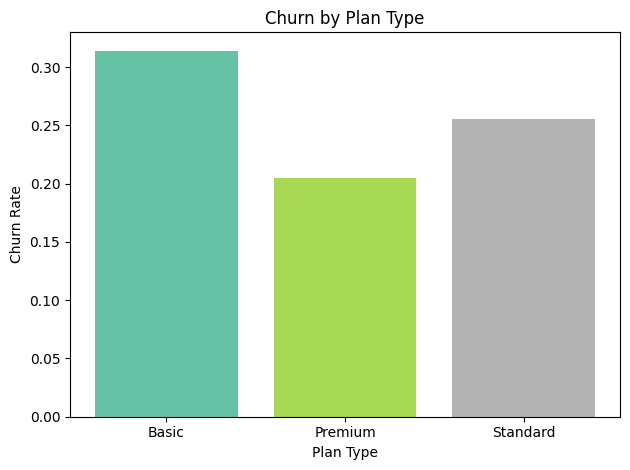

In [67]:
colors = plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.title('Churn by Plan Type')
plt.tight_layout()
plt.show()

In [68]:
# Churn by states
churn_by_state = df_visual.groupby('state')['churned'].mean()

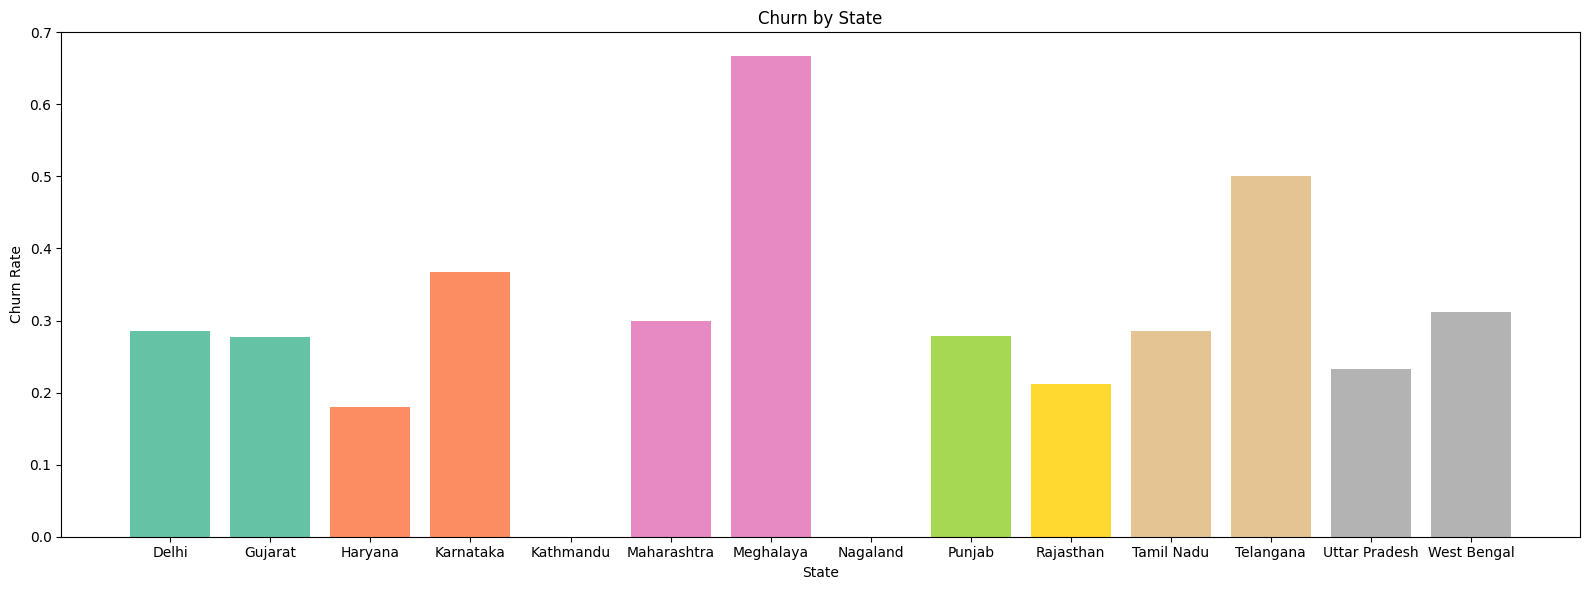

In [69]:
plt.figure(figsize=(16, 6))
colors = plt.cm.Set2(np.linspace(0,1, len(churn_by_state)))
plt.bar(churn_by_state.index, churn_by_state.values, color=colors)
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.title('Churn by State')
plt.tight_layout()
plt.show()

In [70]:
# Encoding
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churned', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'Tenure_days', 'churn_risk'],
      dtype='object')

In [71]:
df_encoded = df_visual[['plan_type','contract_type','churn_score','churned', 'churn_risk','escalations']]

In [72]:
df['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [73]:
order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['Low', 'Medium', 'High']
}

for col, order in order_mappings.items() :
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [74]:
df_encoded.head()

,plan_type,contract_type,churn_score,churned,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

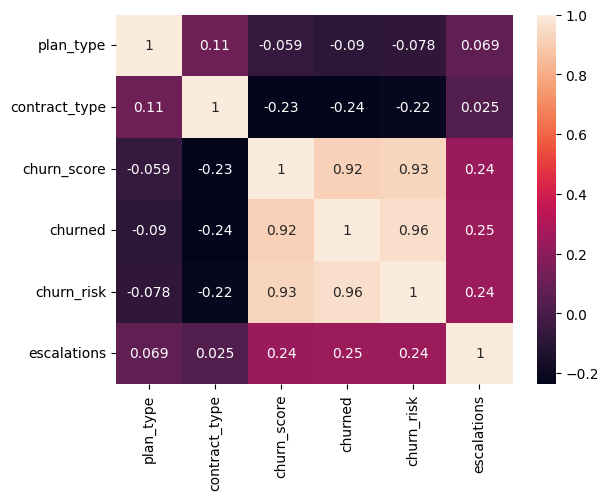

In [75]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

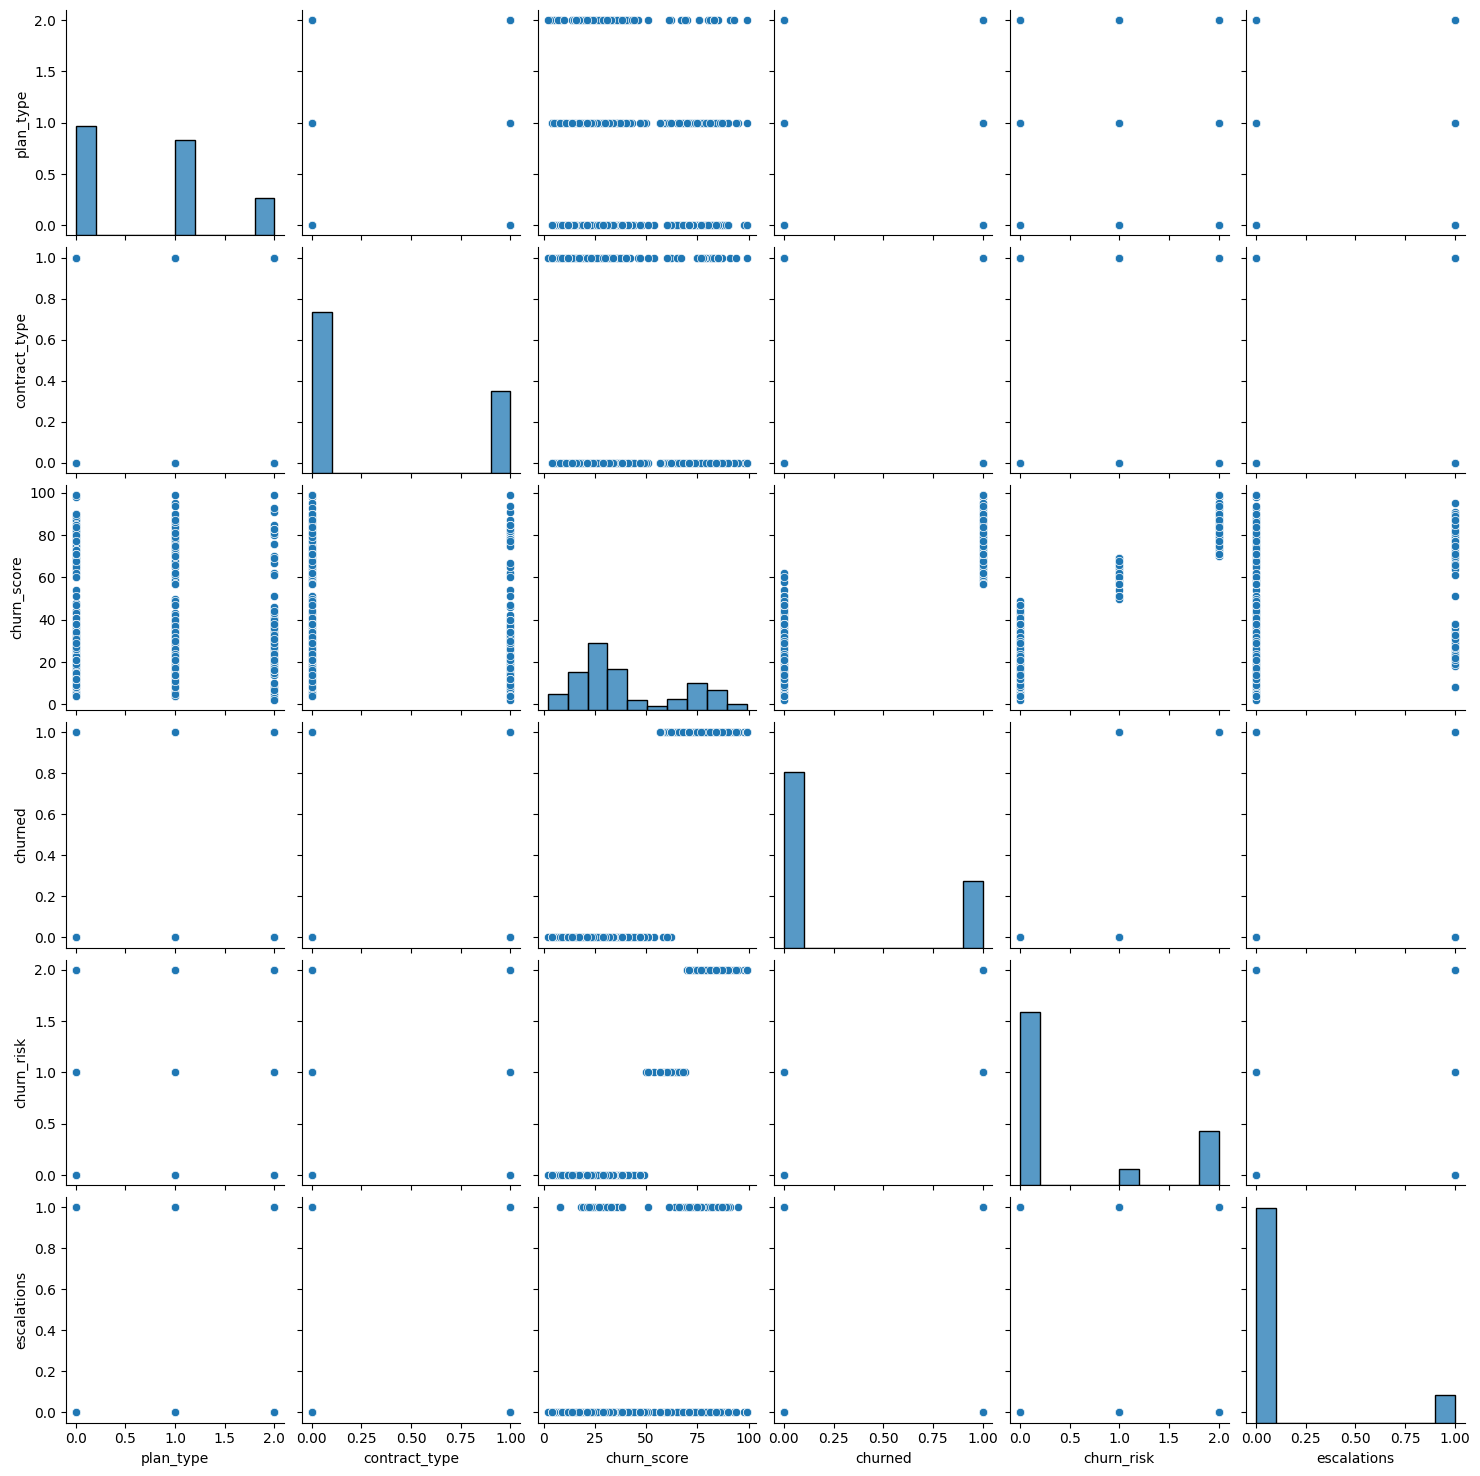

In [76]:
# Pairplot - relationship in a dataset
sns.pairplot(df_encoded)

---

# Pivot Table

In [77]:
pd.pivot_table(
    df_visual,
    values = 'churned',
    index = 'plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churned
0,Basic,0.314159
1,Premium,0.205128
2,Standard,0.255102


In [78]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['churned', 'monthly_charges', 'customerid'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churned' : 'mean'
    }
).reset_index()

,plan_type,churned,customerid,monthly_charges
0,Basic,0.314159,226,1766.74
1,Premium,0.205128,78,2073.22
2,Standard,0.255102,196,3032.04
